Importing necessary libraries 

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

Importing OpenRocket dataset

In [41]:
CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parents[0]
ROCKET_DIR = PROJECT_ROOT / "01_rocket_sizing"

CSV_FILE = ROCKET_DIR / "release_states_data_clean.csv"

if not CSV_FILE.exists():
    raise FileNotFoundError(f"Cleaned dataset not found:\n{CSV_FILE}")

df = pd.read_csv(CSV_FILE)

print("=" * 70)
print("OPENROCKET DATASET LOADED SUCCESSFULLY")
print("=" * 70)

print(f"\nFile: {CSV_FILE.name}")
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")

print("\nFirst 5 rows:")
display(df.head())

OPENROCKET DATASET LOADED SUCCESSFULLY

File: release_states_data_clean.csv
Dataset shape: 1059 rows × 58 columns

First 5 rows:


,Time (s),Altitude (m),Altitude above sea level (m),Vertical velocity (m/s),Total velocity (m/s),Vertical acceleration (m/s²),Total acceleration (m/s²),Position East of launch (m),Position North of launch (m),Lateral distance (m),...,Air pressure (mbar),Air density (g/cm³),Speed of sound (m/s),Mach number (​),Reynolds number (​),Reference length (cm),Reference area (cm²),Simulation time step (s),Computation time (s),Coriolis acceleration (m/s²)
0,0.000,0.000000,0.000000,0.000,0.000,0.000,0.000,0.000000,0.0,0.000000,...,1013.250,0.001,340.389,0.007,199900.0,10,78.54,0.010,0.002,0.000000
1,0.010,0.000039,0.000039,0.028,0.028,12.147,12.147,-0.000003,0.0,0.000003,...,1013.250,0.001,340.389,0.007,199100.0,10,78.54,0.010,0.003,0.000004
2,0.020,0.001000,0.001000,0.259,0.259,34.094,34.095,-0.000014,0.0,0.000014,...,1013.250,0.001,340.389,0.007,199600.0,10,78.54,0.011,0.003,0.000033
3,0.031,0.007000,0.007000,0.767,0.767,58.247,58.247,-0.000035,0.0,0.000035,...,1013.249,0.001,340.389,0.007,208200.0,10,78.54,0.010,0.004,0.000098
4,0.041,0.017000,0.017000,1.361,1.361,60.466,60.466,-0.000064,0.0,0.000064,...,1013.248,0.001,340.389,0.008,228700.0,10,78.54,0.010,0.004,0.000174


Extracting required columns from the dataset

In [42]:
required_columns = [
    "Time (s)",
    "Altitude (m)",
    "Vertical velocity (m/s)",
    "Total velocity (m/s)",
    "Vertical acceleration (m/s²)",
    "Total acceleration (m/s²)",
    "Position East of launch (m)",
    "Position North of launch (m)",
    "Lateral velocity (m/s)",
    "Lateral acceleration (m/s²)",
    "Lateral orientation (azimuth) (°)",
    "Vertical orientation (zenith) (°)"
]

missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

if missing_columns:
    print("Missing columns:")
    
    for column in missing_columns:
        print("-", column)

else:
    rocket_df = df[required_columns].copy()

    print("All required columns found successfully.")
    print(f"\nRocket trajectory points: {len(rocket_df)}")

    display(rocket_df.head())

All required columns found successfully.

Rocket trajectory points: 1059


,Time (s),Altitude (m),Vertical velocity (m/s),Total velocity (m/s),Vertical acceleration (m/s²),Total acceleration (m/s²),Position East of launch (m),Position North of launch (m),Lateral velocity (m/s),Lateral acceleration (m/s²),Lateral orientation (azimuth) (°),Vertical orientation (zenith) (°)
0,0.000,0.000000,0.000,0.000,0.000,0.000,0.000000,0.0,0.000000,0.000,0.0,90.0
1,0.010,0.000039,0.028,0.028,12.147,12.147,-0.000003,0.0,0.000687,0.082,0.0,90.0
2,0.020,0.001000,0.259,0.259,34.094,34.095,-0.000014,0.0,0.002000,0.082,0.0,90.0
3,0.031,0.007000,0.767,0.767,58.247,58.247,-0.000035,0.0,0.002000,0.088,0.0,90.0
4,0.041,0.017000,1.361,1.361,60.466,60.466,-0.000064,0.0,0.003000,0.103,0.0,90.0


Finding apogee data

In [43]:
apogee_index = rocket_df["Altitude (m)"].idxmax()
apogee_state = rocket_df.loc[apogee_index]

print("=" *60)
print("APOGEE / PGV RELEASE STATE")
print("=" * 60)

print(f"\nDataset index: {apogee_index}")

for variable, value in apogee_state.items():
    print(f"{variable}: {value}")

APOGEE / PGV RELEASE STATE

Dataset index: 411
Time (s): 18.492
Altitude (m): 1939.571
Vertical velocity (m/s): 0.005
Total velocity (m/s): 6.533
Vertical acceleration (m/s²): -8.902
Total acceleration (m/s²): 8.911
Position East of launch (m): 223.011
Position North of launch (m): 0.135
Lateral velocity (m/s): 6.533
Lateral acceleration (m/s²): 0.392
Lateral orientation (azimuth) (°): 89.935
Vertical orientation (zenith) (°): 14.773


Defining release states

In [44]:
t0 = apogee_state["Time (s)"]

x0 = apogee_state["Position East of launch (m)"]
y0 = apogee_state["Position North of launch (m)"]
z0 = apogee_state["Altitude (m)"]

vv0 = apogee_state["Vertical velocity (m/s)"]
vt0 = apogee_state["Total velocity (m/s)"]
vl0 = apogee_state["Lateral velocity (m/s)"]

az0 = apogee_state["Lateral orientation (azimuth) (°)"]
ze0 = apogee_state["Vertical orientation (zenith) (°)"]

print("=" * 55)
print("PGV INITIAL RELEASE CONDITIONS")
print("=" * 55)

print(f"\nTime: {t0:.2f} s")

print(f"\nPosition:")
print(f"X: {x0:.2f} m")
print(f"Y: {y0:.2f} m")
print(f"Z: {z0:.2f} m")

print(f"\nVelocity:")
print(f"Vertical: {vv0:.2f} m/s")
print(f"Total:    {vt0:.2f} m/s")
print(f"Lateral:  {vl0:.2f} m/s")

print(f"\nOrientation:")
print(f"Azimuth: {az0:.2f}°")
print(f"Zenith:  {ze0:.2f}°")

PGV INITIAL RELEASE CONDITIONS

Time: 18.49 s

Position:
X: 223.01 m
Y: 0.14 m
Z: 1939.57 m

Velocity:
Vertical: 0.01 m/s
Total:    6.53 m/s
Lateral:  6.53 m/s

Orientation:
Azimuth: 89.94°
Zenith:  14.77°


Mission Feasibility Check

In [45]:
# Target definition
xT = 4000.0
yT = 3000.0

# Baseline PGV performance assumptions (see RAPID Master System Parameters)
Vh = 6.2   # m/s, assumed constant horizontal glide speed
Vz = -1.92 # m/s, assumed constant sink rate

D = np.sqrt((xT - x0) ** 2 + (yT - y0) ** 2)

t_ground = z0 / abs(Vz)

D_max = Vh * t_ground

reachable = D <= D_max

required_Vh = D / t_ground

print("=" * 70)
print("V0 MISSION FEASIBILITY CHECK")
print("=" * 70)

print(f"\nHorizontal distance to target: {D:.2f} m")
print(f"Available flight time: {t_ground:.2f} s")
print(f"Maximum horizontal distance: {D_max:.2f} m")
print(f"Required horizontal speed: {required_Vh:.2f} m/s")

print("\nTARGET IS REACHABLE" if reachable else "\nTARGET IS NOT REACHABLE")
print("=" * 70)


V0 MISSION FEASIBILITY CHECK

Horizontal distance to target: 4823.36 m
Available flight time: 1010.19 s
Maximum horizontal distance: 6263.20 m
Required horizontal speed: 4.77 m/s

TARGET IS REACHABLE


Checking PGV remaining altitude if it reaches the target

In [46]:
t_target = D / Vh

altitude_lost = abs(Vz) * t_target

z_target = z0 - altitude_lost

print("=" * 60)
print("ALTITUDE AT TARGET")
print("=" * 60)

print(f"\nTime to reach target: {t_target:.2f} s")
print(f"Altitude lost: {altitude_lost:.2f} m")
print(f"Remaining altitude at target: {z_target:.2f} m")

if z_target > 0:
    print("\nPGV REACHES THE TARGET WITH ALTITUDE REMAINING")
else:
    print("\nPGV REACHES THE GROUND BEFORE THE TARGET")

ALTITUDE AT TARGET

Time to reach target: 777.96 s
Altitude lost: 1493.69 m
Remaining altitude at target: 445.88 m

PGV REACHES THE TARGET WITH ALTITUDE REMAINING


Impact point if PGV range exeeds target distance

In [47]:
dx = xT - x0
dy = yT - y0

ux = dx / D
uy = dy / D

x_land = x0 + D_max * ux
y_land = y0 + D_max * uy

print("=" * 60)
print("GROUND IMPACT POINT")
print("=" * 60)

print(f"\nLanding X position: {x_land:.2f} m")
print(f"Landing Y position: {y_land:.2f} m")
print(f"Landing altitude: 0.00 m")

print(f"\nDistance travelled beyond target: {D_max - D:.2f} m")

GROUND IMPACT POINT

Landing X position: 5127.48 m
Landing Y position: 3895.50 m
Landing altitude: 0.00 m

Distance travelled beyond target: 1439.83 m


3D Mission Geometry


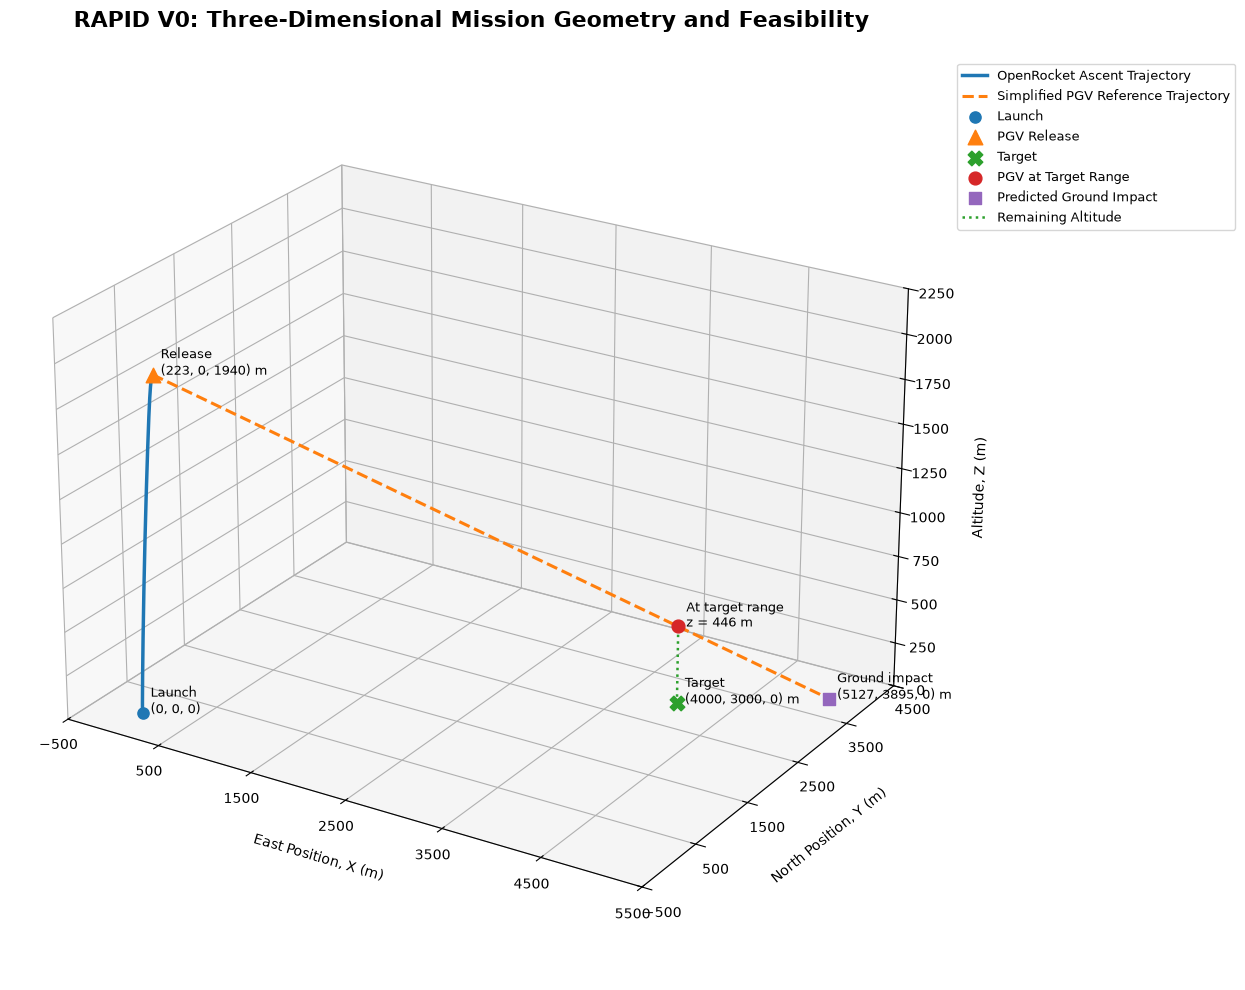

In [48]:
rx = rocket_df["Position East of launch (m)"].to_numpy()
ry = rocket_df["Position North of launch (m)"].to_numpy()
rz = rocket_df["Altitude (m)"].to_numpy()

apogee_pos = np.argmax(rz)

rx = rx[:apogee_pos + 1]
ry = ry[:apogee_pos + 1]
rz = rz[:apogee_pos + 1]

n = 500

s = np.linspace(0, 1, n)

x_pgv = x0 + s * (x_land - x0)
y_pgv = y0 + s * (y_land - y0)
z_pgv = z0 * (1 - s)

fig = plt.figure(figsize=(13, 10))

ax = fig.add_subplot(111, projection="3d")

ax.plot(
    rx,
    ry,
    rz,
    linewidth=2.5,
    label="OpenRocket Ascent Trajectory"
)

ax.plot(
    x_pgv,
    y_pgv,
    z_pgv,
    linewidth=2.2,
    linestyle="--",
    label="Simplified PGV Reference Trajectory"
)

ax.scatter(
    0,
    0,
    0,
    s=65,
    marker="o",
    label="Launch"
)

ax.scatter(
    x0,
    y0,
    z0,
    s=110,
    marker="^",
    label="PGV Release"
)

ax.scatter(
    xT,
    yT,
    0,
    s=110,
    marker="X",
    label="Target"
)

ax.scatter(
    xT,
    yT,
    z_target,
    s=85,
    marker="o",
    label="PGV at Target Range"
)

ax.scatter(
    x_land,
    y_land,
    0,
    s=85,
    marker="s",
    label="Predicted Ground Impact"
)

ax.plot(
    [xT, xT],
    [yT, yT],
    [0, z_target],
    linestyle=":",
    linewidth=1.8,
    label="Remaining Altitude"
)

ax.text(
    0,
    0,
    0,
    "  Launch\n  (0, 0, 0)",
    fontsize=9
)

ax.text(
    x0,
    y0,
    z0,
    f"  Release\n  ({x0:.0f}, {y0:.0f}, {z0:.0f}) m",
    fontsize=9
)

ax.text(
    xT,
    yT,
    0,
    f"  Target\n  ({xT:.0f}, {yT:.0f}, 0) m",
    fontsize=9
)

ax.text(
    xT,
    yT,
    z_target,
    f"  At target range\n  z = {z_target:.0f} m",
    fontsize=9
)

ax.text(
    x_land,
    y_land,
    0,
    f"  Ground impact\n  ({x_land:.0f}, {y_land:.0f}, 0) m",
    fontsize=9
)

ax.set_xlabel("East Position, X (m)", labelpad=12)
ax.set_ylabel("North Position, Y (m)", labelpad=12)
ax.set_zlabel("Altitude, Z (m)", labelpad=12)

ax.set_title(
    "RAPID V0: Three-Dimensional Mission Geometry and Feasibility",
    fontsize=16,
    fontweight="bold",
    pad=22
)

x_min = min(0, np.min(rx), x0, xT, x_land)
x_max = max(0, np.max(rx), x0, xT, x_land)

y_min = min(0, np.min(ry), y0, yT, y_land)
y_max = max(0, np.max(ry), y0, yT, y_land)

z_max = max(np.max(rz), z0)

x_margin = 350
y_margin = 350
z_margin = 150

ax.set_xlim(x_min - x_margin, x_max + x_margin)
ax.set_ylim(y_min - y_margin, y_max + y_margin)
ax.set_zlim(0, z_max + z_margin)

ax.set_xticks(
    np.arange(
        -500,
        np.ceil((x_max + x_margin) / 1000) * 1000 + 1,
        1000
    )
)

ax.set_yticks(
    np.arange(
        -500,
        np.ceil((y_max + y_margin) / 1000) * 1000 + 1,
        1000
    )
)

ax.set_zticks(
    np.arange(
        0,
        np.ceil((z_max + z_margin) / 250) * 250 + 1,
        250
    )
)

ax.set_box_aspect(
    (
        x_max - x_min,
        y_max - y_min,
        0.65 * (x_max - x_min)
    )
)

ax.grid(True)

ax.view_init(
    elev=24,
    azim=-58
)

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    fontsize=9,
    frameon=True
)

plt.tight_layout()

plt.show()

Horizontal Mission Geometry

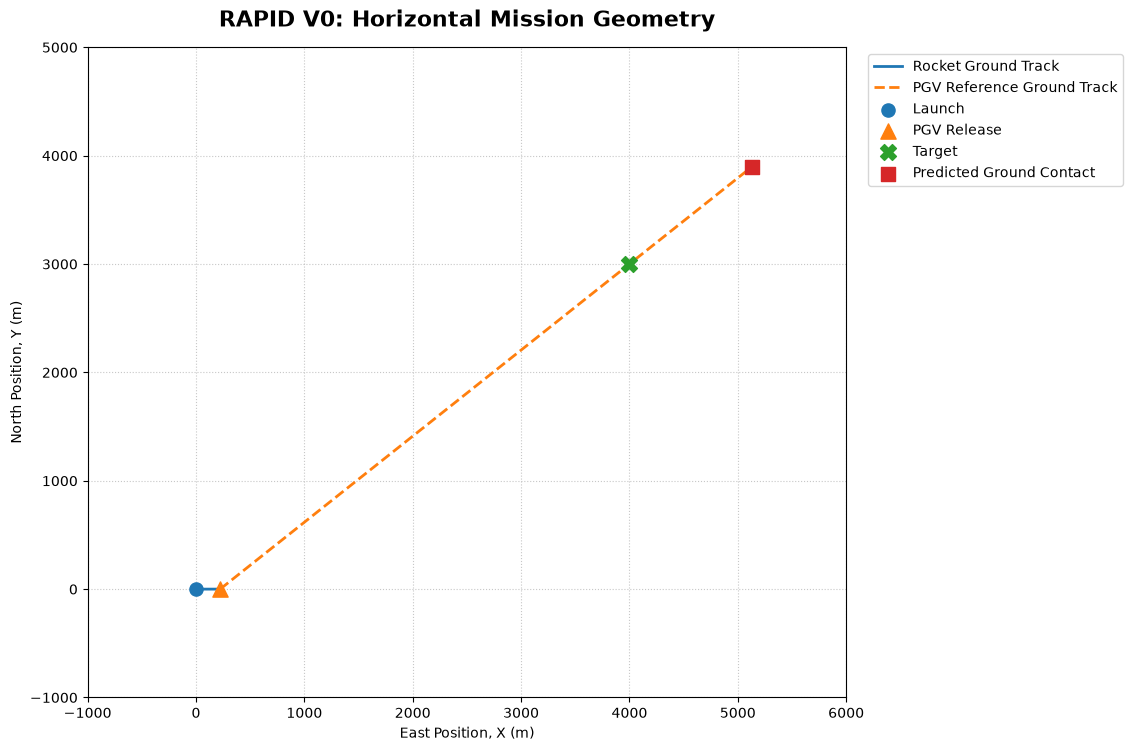

In [49]:
fig, ax = plt.subplots(figsize=(11, 9))

ax.plot(
    rx,
    ry,
    linewidth=2,
    label="Rocket Ground Track"
)

ax.plot(
    x_pgv,
    y_pgv,
    linewidth=2,
    linestyle="--",
    label="PGV Reference Ground Track"
)

ax.scatter(
    0,
    0,
    s=90,
    marker="o",
    label="Launch",
    zorder=5
)

ax.scatter(
    x0,
    y0,
    s=120,
    marker="^",
    label="PGV Release",
    zorder=5
)

ax.scatter(
    xT,
    yT,
    s=130,
    marker="X",
    label="Target",
    zorder=5
)

ax.scatter(
    x_land,
    y_land,
    s=100,
    marker="s",
    label="Predicted Ground Contact",
    zorder=5
)

ax.set_xlabel("East Position, X (m)")
ax.set_ylabel("North Position, Y (m)")

ax.set_title(
    "RAPID V0: Horizontal Mission Geometry",
    fontsize=16,
    fontweight="bold",
    pad=15
)

x_min = min(0, np.min(rx), x0, xT, x_land)
x_max = max(0, np.max(rx), x0, xT, x_land)

y_min = min(0, np.min(ry), y0, yT, y_land)
y_max = max(0, np.max(ry), y0, yT, y_land)

x_margin = 0.08 * (x_max - x_min)
y_margin = 0.08 * (y_max - y_min)

ax.set_xlim(x_min - x_margin, x_max + x_margin)
ax.set_ylim(y_min - y_margin, y_max + y_margin)

ax.set_xticks(
    np.arange(
        np.floor((x_min - x_margin) / 1000) * 1000,
        np.ceil((x_max + x_margin) / 1000) * 1000 + 1,
        1000
    )
)

ax.set_yticks(
    np.arange(
        np.floor((y_min - y_margin) / 1000) * 1000,
        np.ceil((y_max + y_margin) / 1000) * 1000 + 1,
        1000
    )
)

ax.grid(True, linestyle=":", alpha=0.7)

ax.set_aspect("equal", adjustable="box")

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    frameon=True
)

plt.tight_layout()

plt.show()

Altitude vs Horizontal Distance

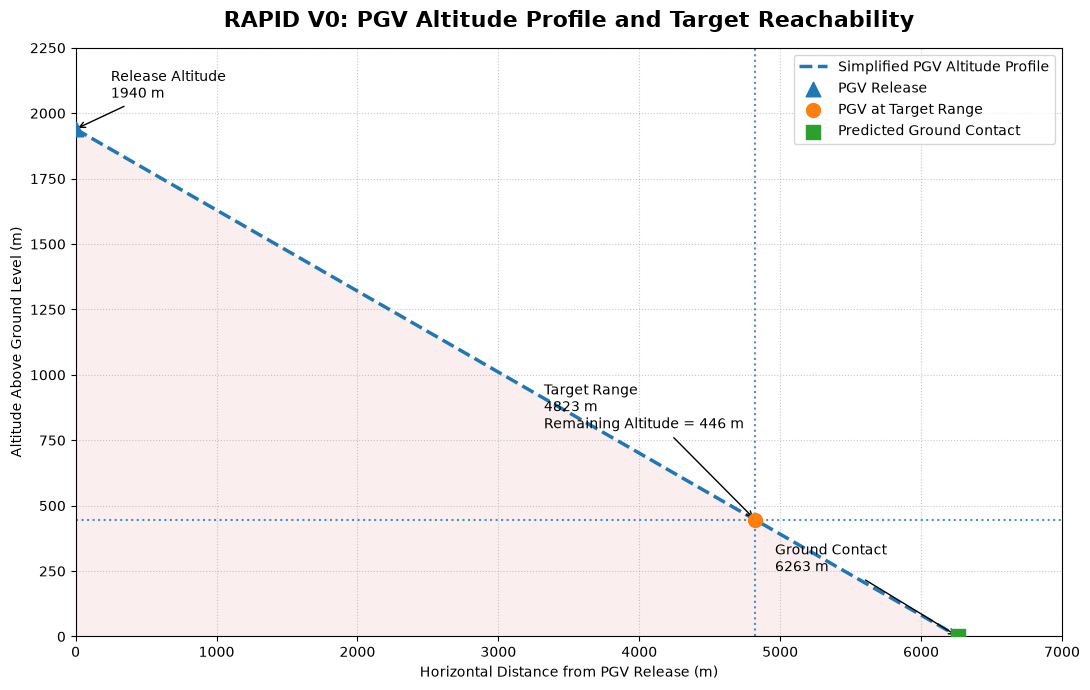

In [50]:
pgv_distance = np.sqrt(
    (x_pgv - x0) ** 2 +
    (y_pgv - y0) ** 2
)

target_distance = np.sqrt(
    (xT - x0) ** 2 +
    (yT - y0) ** 2
)

fig, ax = plt.subplots(figsize=(11, 7))

ax.plot(
    pgv_distance,
    z_pgv,
    linewidth=2.5,
    linestyle="--",
    label="Simplified PGV Altitude Profile"
)

ax.scatter(
    0,
    z0,
    s=110,
    marker="^",
    label="PGV Release",
    zorder=5
)

ax.scatter(
    target_distance,
    z_target,
    s=100,
    marker="o",
    label="PGV at Target Range",
    zorder=5
)

ax.scatter(
    pgv_distance[-1],
    0,
    s=100,
    marker="s",
    label="Predicted Ground Contact",
    zorder=5
)

ax.axvline(
    target_distance,
    linestyle=":",
    linewidth=1.5,
    alpha=0.8
)

ax.axhline(
    z_target,
    linestyle=":",
    linewidth=1.5,
    alpha=0.8
)

ax.annotate(
    f"Release Altitude\n{z0:.0f} m",
    xy=(0, z0),
    xytext=(250, z0 + 120),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

ax.annotate(
    f"Target Range\n{target_distance:.0f} m\nRemaining Altitude = {z_target:.0f} m",
    xy=(target_distance, z_target),
    xytext=(target_distance - 1500, z_target + 350),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

ax.annotate(
    f"Ground Contact\n{pgv_distance[-1]:.0f} m",
    xy=(pgv_distance[-1], 0),
    xytext=(pgv_distance[-1] - 1300, 250),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

ax.fill_between(
    pgv_distance,
    z_pgv,
    0,
    alpha=0.08
)

ax.set_xlabel("Horizontal Distance from PGV Release (m)")
ax.set_ylabel("Altitude Above Ground Level (m)")

ax.set_title(
    "RAPID V0: PGV Altitude Profile and Target Reachability",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlim(
    0,
    np.ceil(pgv_distance[-1] / 500) * 500
)

ax.set_ylim(
    0,
    np.ceil((z0 + 200) / 250) * 250
)

ax.set_xticks(
    np.arange(
        0,
        np.ceil(pgv_distance[-1] / 1000) * 1000 + 1,
        1000
    )
)

ax.set_yticks(
    np.arange(
        0,
        np.ceil((z0 + 200) / 250) * 250 + 1,
        250
    )
)

ax.grid(True, linestyle=":", alpha=0.7)

ax.legend(
    loc="upper right",
    frameon=True
)

plt.tight_layout()

plt.show()